In [1]:
import math
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from LBFGS import *

In [2]:
class PlateWithHole(keras.Model):
    def __init__(self, network_u, network_v, train_op, num_epoch, data_type):
        super().__init__()
        self.network_u = network_u
        self.network_v = network_v
        self.optimizer = train_op  # store optimizer here
        self.num_epoch = num_epoch
        self.data_type = data_type
        self.print_epoch = 100
        self.network_u.build((None, 2))
        self.network_v.build((None, 2))

    
    @tf.function
    def u(self, X):
        x = X[:, 0:1]
        X1 = self.network_u(X)
        return X1*x
    
    @tf.function
    def v(self, X):
        y = X[:, 1:2]
        X1 = self.network_v(X)
        return X1*y
    
    @tf.function
    def call(self, X):
        uVal = self.u(X)
        vVal = self.v(X)
        disp = tf.concat([uVal, vVal], axis=1)
        return disp
    
    @tf.function
    def strains(self, x, y):
        with tf.GradientTape(persistent=True) as tape:
            tape.watch(x)
            tape.watch(y)
            X = tf.concat([x, y], axis=1)
            U = self.u(X)
            V = self.v(X)
        du_dx = tape.gradient(U, x)
        du_dy = tape.gradient(U, y)
        dv_dx = tape.gradient(V, x)
        dv_dy = tape.gradient(V, y)
        del tape
        epsilon_xx = du_dx
        epsilon_yy = dv_dy
        epsilon_xy = (du_dy + dv_dx)
        return epsilon_xx, epsilon_yy, epsilon_xy
    
    @tf.function
    def stresses(self, x, y):
        E = 5
        nu = 0.3
        epsilon_xx, epsilon_yy, epsilon_xy = self.strains(x, y)
        sigma_xx = E / (1 - nu**2) * (epsilon_xx + nu * epsilon_yy)
        sigma_yy = E / (1 - nu**2) * (epsilon_yy + nu * epsilon_xx)
        sigma_xy = E / (2 * (1 + nu)) * epsilon_xy
        return sigma_xx, sigma_yy, sigma_xy
    
    @tf.function
    def equilibrium(self, x, y):
        with tf.GradientTape(persistent=True) as tape:
            tape.watch(x)
            tape.watch(y)
            sigma_xx, sigma_yy, sigma_xy = self.stresses(x, y)
        dsigma_xx_dx = tape.gradient(sigma_xx, x)
        dsigma_xy_dy = tape.gradient(sigma_xy, y)
        dsigma_yy_dy = tape.gradient(sigma_yy, y)
        dsigma_xy_dx = tape.gradient(sigma_xy, x)
        del tape
        
        return dsigma_xx_dx, dsigma_yy_dy, dsigma_xy_dy, dsigma_xy_dx
    
    @tf.function
    def loss_all(self, X_dom, Y_dom):
        dsigma_xx_dx, dsigma_yy_dy, dsigma_xy_dy, dsigma_xy_dx = self.equilibrium(X_dom[:, 0:1], X_dom[:, 1:2])
        ge_x = dsigma_xx_dx + dsigma_xy_dy
        ge_y = dsigma_yy_dy + dsigma_xy_dx
        loss_eq = tf.reduce_mean(tf.square(ge_x)) + tf.reduce_mean(tf.square(ge_y))
        
        Lx = 1.0
        Ly = 1.0
        r = 0.2
        ns_a = 51
        ns_u = 101
        ns_b = 101
        ns_l = 101
        ns_r = 101
        dx = Lx / (ns_u - 1)
        h = dx * 5
        
        # Top boundary
        x_u = np.linspace(0, Lx, ns_u).reshape(-1, 1).astype(np.float32)
        y_u = np.ones((ns_u, 1), dtype=np.float32)
        sigma_xx_u, sigma_yy_u, sigma_xy_u = self.stresses(x_u, y_u)
        loss_boundary_D1 =  tf.reduce_mean(tf.square(sigma_yy_u)) + tf.reduce_mean(tf.square(sigma_xy_u))
        
        # Bottom boundary
        x_b = np.linspace(r, Lx, ns_b).reshape(-1, 1).astype(np.float32)
        y_b = np.zeros((ns_b, 1), dtype=np.float32)
        sigma_xx_b, sigma_yy_b, sigma_xy_b = self.stresses(x_b, y_b)
        loss_boundary_D2 = tf.reduce_mean(tf.square(sigma_xy_b))
        
        # Left boundary
        x_l = np.zeros((ns_l, 1), dtype=np.float32)
        y_l = np.linspace(0, Ly, ns_l).reshape(-1, 1).astype(np.float32)
        sigma_xx_l, sigma_yy_l, sigma_xy_l = self.stresses(x_l, y_l)
        loss_boundary_D3 = tf.reduce_mean(tf.square(sigma_xy_l))
        
        # Right boundary
        x_r = np.ones((ns_r, 1), dtype=np.float32) * Lx
        y_r = np.linspace(0, Ly, ns_r).reshape(-1, 1).astype(np.float32)
        sigma_xx_r, sigma_yy_r, sigma_xy_r = self.stresses(x_r, y_r)
        loss_boundary_D4 = tf.reduce_mean(tf.square(sigma_xy_r)) + tf.reduce_mean(tf.square(sigma_xx_r - 1.0))
        
        #Arc boundary
        xy_a = np.zeros((ns_a, 2), dtype=np.float32)
        theta = np.pi/((ns_a - 1) * 2)
        for i in range(ns_a):
            xy_a[i, 0] = r * math.cos(i * theta)
            xy_a[i, 1] = r * math.sin(i * theta)
            
        xy_a[-1, 0] = 0
        xy_a[-1, 1] = r
        
        
        angle = np.zeros((ns_a, 1), dtype=np.float32)
        for i in range(ns_a):
            angle[i, 0] = theta * i
        
        n1x = -np.cos(angle)
        n1y = -np.sin(angle)
        n1x[-1] = 0
        n1y[-1] = -1
        
        xarc = xy_a[:, 0:1]
        yarc = xy_a[:, 1:2]
        
        nx = tf.convert_to_tensor(n1x)
        ny = tf.convert_to_tensor(n1y)
        
        sigma_xx_arc, sigma_yy_arc, sigma_xy_arc = self.stresses(xarc, yarc)
        
        loss_boundary_D5 = tf.reduce_mean(tf.square(sigma_xx_arc * nx + sigma_xy_arc * ny)) + \
                          tf.reduce_mean(tf.square(sigma_xy_arc * nx + sigma_yy_arc * ny))
        loss_boundary = loss_boundary_D1 + loss_boundary_D2 + loss_boundary_D3 + loss_boundary_D4 + loss_boundary_D5
        
        return loss_eq, loss_boundary
    
    @tf.function
    def loss_grad(self, X_dom, Y_dom):
        with tf.GradientTape() as tape:
            #tape.watch(self.trainable_variables)
            loss_eq, loss_boundary = self.loss_all(X_dom, Y_dom)
            losses = loss_eq + loss_boundary
        grad = tape.gradient(losses, self.trainable_variables)
        return loss_eq, loss_boundary, losses, grad
    
    #@tf.function
    def train(self, X_dom, Y_dom):
        for epoch in range(self.num_epoch):
            with tf.GradientTape() as tape:
                loss_val1, loss_val2 = self.loss_all(X_dom, Y_dom)
                loss_val = loss_val1 + loss_val2
                grads = tape.gradient(loss_val, self.trainable_variables)
            self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

            if (epoch + 1) % self.print_epoch == 0:
                print("Epoch:", epoch + 1, "Loss:", loss_val.numpy())


In [3]:
Lx = 1.0
Ly = 1.0
r = 0.2
num_points = 100
x = np.linspace(0, Lx, num_points)
y = np.linspace(0, Ly, num_points)
X, Y = np.meshgrid(x, y)
points = np.stack((X.flatten(), Y.flatten()), axis=1)
distances = np.sqrt(points[:, 0]**2 + points[:, 1]**2)
valid_points = points[distances > r]
x_domain = valid_points
y_domain = np.zeros_like(x_domain)

In [4]:
data_type = 'float32'
X_dom_tf = tf.convert_to_tensor(x_domain, dtype=tf.float32)
Y_dom_tf = tf.convert_to_tensor(y_domain, dtype=tf.float32)
tf.keras.backend.set_floatx(data_type)

# Define the neural networks for u and v
network_u = keras.Sequential([
    keras.layers.Dense(20, activation='tanh'),
    keras.layers.Dense(20, activation='tanh'),
    keras.layers.Dense(20, activation='tanh'),
    keras.layers.Dense(1)
])

network_v = keras.Sequential([
    keras.layers.Dense(20, activation='tanh'),
    keras.layers.Dense(20, activation='tanh'),
    keras.layers.Dense(20, activation='tanh'),
    keras.layers.Dense(1)
])

train_op = tf.keras.optimizers.Adam(learning_rate=0.005)
num_epoch = 100
pred_model = PlateWithHole(network_u, network_v, train_op, num_epoch, data_type)
# Train the model
pred_model.train(X_dom_tf, Y_dom_tf)

Epoch: 100 Loss: 0.16713098


In [5]:
l_bfgs_b = Opt_lbfgsb(pred_model, X_dom_tf, Y_dom_tf)
result = l_bfgs_b.fit()

Optimizer: L-BFGS-B (Provided by Scipy package)
Initializing the framework ...
Iteration: 1 Loss = 0.16674297 
Iteration: 2 Loss = 410.4046 
Iteration: 3 Loss = 0.16667317 
Iteration: 4 Loss = 0.1666406 
Iteration: 5 Loss = 0.16656181 
Iteration: 6 Loss = 0.16637456 
Iteration: 7 Loss = 0.1659263 
Iteration: 8 Loss = 0.16466932 
Iteration: 9 Loss = 0.16283442 
Iteration: 10 Loss = 0.16104019 
Iteration: 11 Loss = 0.16034248 
Iteration: 12 Loss = 0.16014868 
Iteration: 13 Loss = 0.1600521 
Iteration: 14 Loss = 0.1598041 
Iteration: 15 Loss = 0.1595095 
Iteration: 16 Loss = 0.15930623 
Iteration: 17 Loss = 0.15902622 
Iteration: 18 Loss = 0.15876888 
Iteration: 19 Loss = 0.15833226 
Iteration: 20 Loss = 0.15723039 
Iteration: 21 Loss = 0.15549362 
Iteration: 22 Loss = 0.15359771 
Iteration: 23 Loss = 0.1522286 
Iteration: 24 Loss = 0.15225662 
Iteration: 25 Loss = 0.15141687 
Iteration: 26 Loss = 0.15117544 
Iteration: 27 Loss = 0.15084496 
Iteration: 28 Loss = 0.15044066 
Iteration: 29 

In [6]:
Lx = 1.0
Ly = 1.0    
r = 0.2

num_points = 120
x = np.linspace(0, Lx, num_points, dtype=np.float32)
y = np.linspace(0, Ly, num_points, dtype=np.float32)
X, Y = np.meshgrid(x, y)
points = np.stack((X.flatten(), Y.flatten()), axis=1)
distances = np.sqrt(points[:, 0]**2 + points[:, 1]**2)
valid_points = points[distances > r]
x_domain = valid_points
X = x_domain[:, 0:1]
Y = x_domain[:, 1:2]

predicted_sigma_xx, predicted_sigma_yy, predicted_sigma_xy = pred_model.stresses(X, Y)
predicted_displacement = pred_model(x_domain)
x_disp = predicted_displacement[:, 0:1]
y_disp = predicted_displacement[:, 1:2]

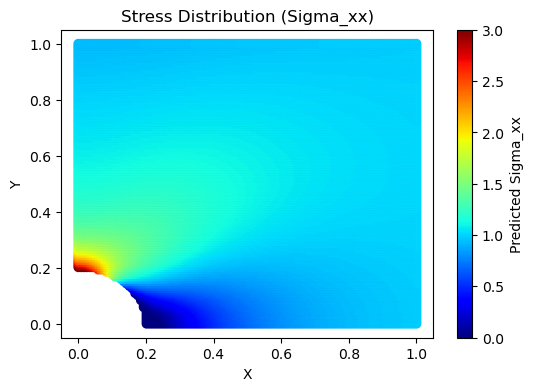

In [7]:
plt.figure(figsize=(6, 4))
scatter = plt.scatter(X.flatten(), Y.flatten(), c=predicted_sigma_xx, cmap='jet', s=50, edgecolors='k', linewidths=0.005, vmax=3, vmin=0)
cbar = plt.colorbar(scatter)
cbar.set_label('Predicted Sigma_xx')

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Stress Distribution (Sigma_xx)')
plt.show()

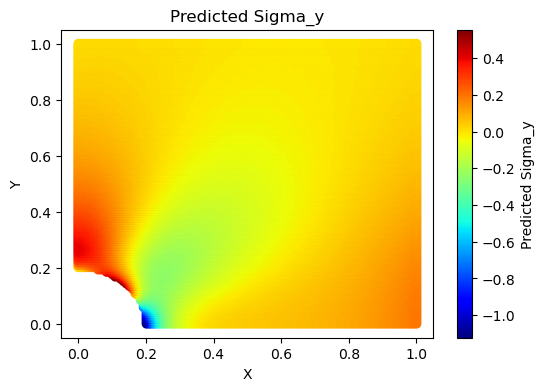

In [8]:

plt.figure(figsize=(6, 4))  # Set the figure size

# Plot the scatter points with MATLAB-like style
scatter = plt.scatter(X.flatten(), Y.flatten(), c=predicted_sigma_yy,\
                       cmap='jet', s=50, edgecolors='k', linewidths=0.005)

# Add colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Predicted Sigma_y')

# Set axis labels and title
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Predicted Sigma_y')
plt.show()


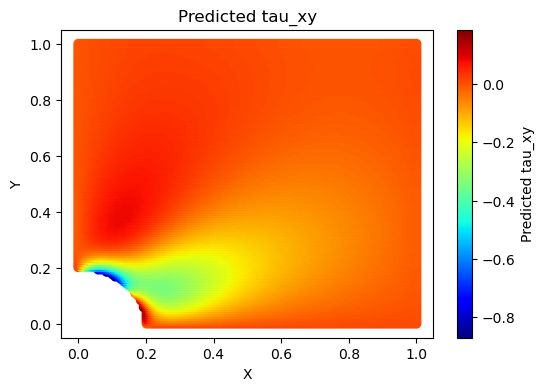

In [9]:
plt.figure(figsize=(6, 4))  # Set the figure size

# Plot the scatter points with MATLAB-like style
scatter = plt.scatter(X.flatten(), Y.flatten(), c=predicted_sigma_xy,\
                       cmap='jet', s=50, edgecolors='k', linewidths=0.005)

# Add colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Predicted tau_xy')

# Set axis labels and title
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Predicted tau_xy')
plt.show()


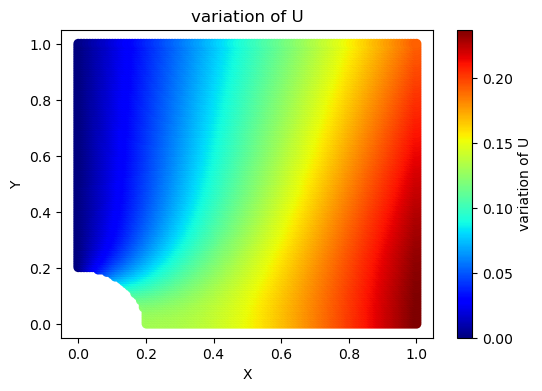

In [10]:
plt.figure(figsize=(6, 4))  # Set the figure size

# Plot the scatter points with MATLAB-like style
scatter = plt.scatter(X.flatten(), Y.flatten(), c=x_disp, \
                      cmap='jet', s=50, edgecolors='k', linewidths=0.005)

# Add colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('variation of U')

# Set axis labels and title
plt.xlabel('X')
plt.ylabel('Y')
plt.title('variation of U')

plt.show()


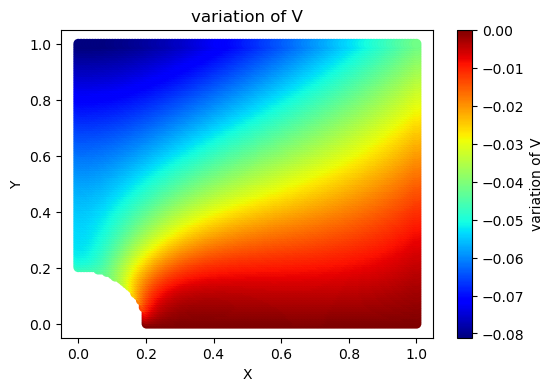

In [11]:
plt.figure(figsize=(6, 4))  # Set the figure size

# Plot the scatter points with MATLAB-like style
scatter = plt.scatter(X.flatten(), Y.flatten(), c=y_disp,\
                       cmap='jet', s=50, edgecolors='k', linewidths=0.005)

# Add colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('variation of V')

# Set axis labels and title
plt.xlabel('X')
plt.ylabel('Y')
plt.title('variation of V')

# Add grid lines
# plt.grid(True, linestyle='--', alpha=0.5)

plt.show()
